<a href="https://colab.research.google.com/github/Rakeentheboss/DecodeLabs-Internship/blob/main/Decode_labs_project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plot


In [4]:
from sklearn.datasets import load_iris
iris = load_iris()

In [5]:
df= pd.DataFrame(iris.data, columns=iris.feature_names)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


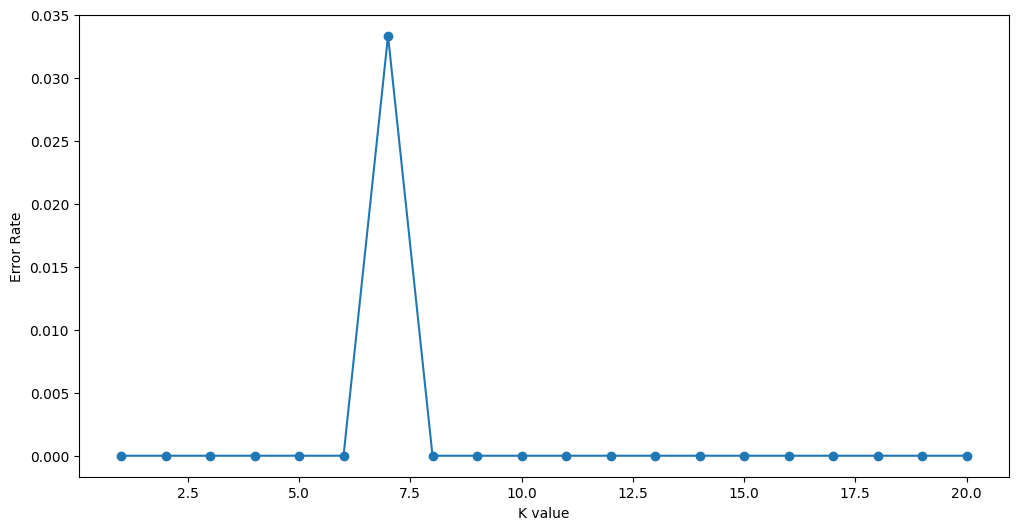

In [26]:
#implement silhouette to determine the k value
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


X=iris.data
y=iris.target

k_value=range(1,21)
error_rates=[]
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=42)

for k in k_value:
    knn= KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    y_pred=knn.predict(X_test)
    error_rate= 1-accuracy_score(y_test,y_pred)
    error_rates.append(error_rate)

plot.figure(figsize=(12,6))
plot.plot(k_value, error_rates, marker='o')
plot.xlabel('K value')
plot.ylabel('Error Rate')
plot.show()




In [27]:


model = KNeighborsClassifier(n_neighbors=6)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)




Accuracy: 1.0


In [31]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score


model.fit(X_train, y_train)
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)


precision=precision_score(y_test,y_pred, average='weighted')
print("Precision:", precision)

recall=recall_score(y_test,y_pred, average='weighted')
print("Recall:", recall)

f1=f1_score(y_test,y_pred, average='weighted')
print("F1 Score:", f1)


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


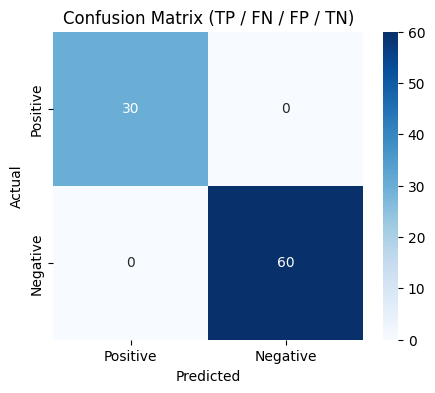

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    multilabel_confusion_matrix
)

# Multilabel confusion matrix
mcm = multilabel_confusion_matrix(y_test, y_pred)

# Combined TP TN FP FN
TP = mcm[:,1,1].sum()
TN = mcm[:,0,0].sum()
FP = mcm[:,0,1].sum()
FN = mcm[:,1,0].sum()

cm = [[TP, FN],
      [FP, TN]]

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Positive", "Negative"],
    yticklabels=["Positive", "Negative"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (TP / FN / FP / TN)")

plt.show()

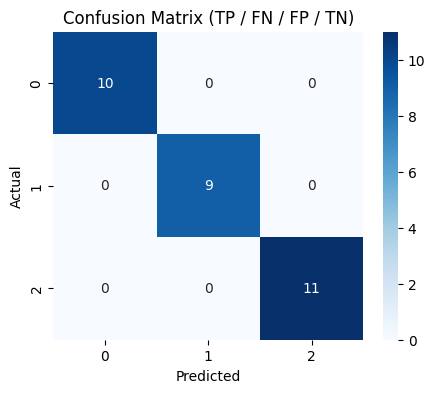

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    multilabel_confusion_matrix
)

# Multilabel confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Combined TP TN FP FN


plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',

)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix (TP / FN / FP / TN)")

plt.show()